# Handling Imbalanced & Messy Real-World Data — Credit Card Fraud Detection

**Goal:** Real datasets are rarely balanced — fraud, disease, and churn cases
are usually rare compared to "normal" cases. This notebook works with a
genuinely extreme imbalance (credit card fraud), shows why accuracy is a
misleading metric here, and applies techniques to properly handle it.

**Dataset:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
(Kaggle) — 284,807 European credit card transactions from September 2013,
with 492 labeled as fraud. Features `V1`-`V28` are PCA-anonymized for
confidentiality; `Time` and `Amount` are the only original, interpretable
columns. Target: `Class` (1 = fraud, 0 = normal).


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("creditcard.csv")
df.shape


(284807, 31)

## 2. Check class balance

In [2]:
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print(class_counts)
print()
print(class_pct.round(4))


Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


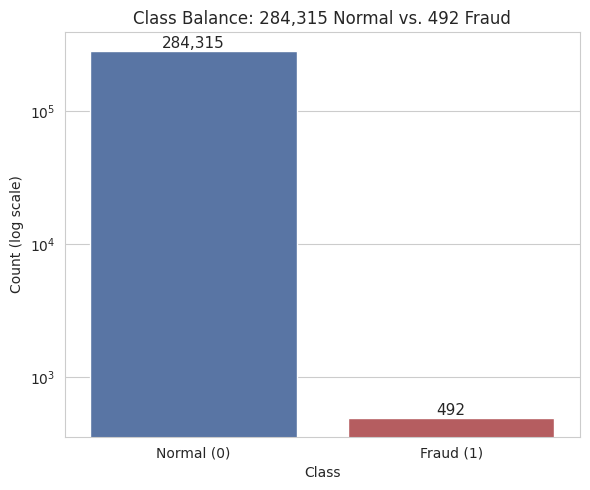

In [3]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x="Class", data=df, hue="Class", palette=["#4C72B0", "#C44E52"], legend=False)
ax.set_yscale("log")
plt.xticks([0, 1], ["Normal (0)", "Fraud (1)"])
plt.ylabel("Count (log scale)")
plt.title(f"Class Balance: {class_counts[0]:,} Normal vs. {class_counts[1]:,} Fraud")
for i, v in enumerate(class_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=11)
plt.tight_layout()
plt.show()


Only **0.17% of transactions are fraud** (492 out of 284,807) — this is an
extreme imbalance, not just a mild one like Titanic's ~62/38 split. A log
scale is needed on the y-axis just to make the fraud bar visible at all next
to the normal bar.


## 3. Prepare features

In [4]:
X = df.drop(columns=["Class"])
y = df["Class"]

# Scale Time and Amount (V1-V28 are already PCA-scaled)
scaler = StandardScaler()
X["Time"] = scaler.fit_transform(X[["Time"]])
X["Amount"] = scaler.fit_transform(X[["Amount"]])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Fraud cases in train:", y_train.sum(), " Fraud cases in test:", y_test.sum())


Train: (227845, 30)  Test: (56962, 30)
Fraud cases in train: 394  Fraud cases in test: 98


## 4. Why would accuracy be misleading here?

With fraud at just 0.17% of transactions, a model that predicts **"not
fraud" for every single transaction** would score **99.83% accuracy** —
an impressive-looking number — while catching precisely zero fraud cases,
which is the entire point of building the model in the first place. Accuracy
rewards getting the overwhelming majority class right and barely penalizes
missing the rare, high-stakes class. For fraud (and disease, and churn),
what actually matters is **recall** (are we catching the fraud that exists?)
and **precision** (when we flag something as fraud, is it usually right?) —
metrics that evaluate performance on the minority class specifically,
instead of being dominated by the majority class like accuracy is.


## 5. Baseline model — trained on the original imbalanced data

In [5]:
baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)

print(f"Accuracy:  {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")
print(f"F1-score:  {baseline_f1:.4f}")
print()
print(classification_report(y_test, y_pred_baseline, target_names=["Normal", "Fraud"], digits=4))


Accuracy:  0.9992
Precision: 0.8289
Recall:    0.6429
F1-score:  0.7241

              precision    recall  f1-score   support

      Normal     0.9994    0.9998    0.9996     56864
       Fraud     0.8289    0.6429    0.7241        98

    accuracy                         0.9992     56962
   macro avg     0.9142    0.8213    0.8619     56962
weighted avg     0.9991    0.9992    0.9991     56962



## 6. Technique 1 — Class weighting (`class_weight='balanced'`)

This tells Logistic Regression to penalize mistakes on the minority class
(fraud) more heavily during training, proportional to how rare it is —
without changing the actual training data.


In [6]:
weighted_model = LogisticRegression(max_iter=1000, class_weight="balanced")
weighted_model.fit(X_train, y_train)
y_pred_weighted = weighted_model.predict(X_test)

weighted_accuracy = accuracy_score(y_test, y_pred_weighted)
weighted_precision = precision_score(y_test, y_pred_weighted)
weighted_recall = recall_score(y_test, y_pred_weighted)
weighted_f1 = f1_score(y_test, y_pred_weighted)

print(f"Accuracy:  {weighted_accuracy:.4f}")
print(f"Precision: {weighted_precision:.4f}")
print(f"Recall:    {weighted_recall:.4f}")
print(f"F1-score:  {weighted_f1:.4f}")
print()
print(classification_report(y_test, y_pred_weighted, target_names=["Normal", "Fraud"], digits=4))


Accuracy:  0.9755
Precision: 0.0609
Recall:    0.9184
F1-score:  0.1141

              precision    recall  f1-score   support

      Normal     0.9999    0.9756    0.9876     56864
       Fraud     0.0609    0.9184    0.1141        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5509     56962
weighted avg     0.9982    0.9755    0.9861     56962



## 7. Technique 2 — SMOTE (Synthetic Minority Over-sampling)

SMOTE generates synthetic fraud examples (rather than just duplicating real
ones) by interpolating between existing fraud cases and their nearest
neighbors, so the training set becomes balanced. **Critically, SMOTE is
applied only to the training data, after the train/test split** — the test
set stays untouched and realistically imbalanced, so evaluation reflects
real-world conditions.


In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_smote.value_counts().to_dict())


Before SMOTE: {0: 227451, 1: 394}
After SMOTE:  {0: 227451, 1: 227451}


In [8]:
smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_smote, y_train_smote)
y_pred_smote = smote_model.predict(X_test)

smote_accuracy = accuracy_score(y_test, y_pred_smote)
smote_precision = precision_score(y_test, y_pred_smote)
smote_recall = recall_score(y_test, y_pred_smote)
smote_f1 = f1_score(y_test, y_pred_smote)

print(f"Accuracy:  {smote_accuracy:.4f}")
print(f"Precision: {smote_precision:.4f}")
print(f"Recall:    {smote_recall:.4f}")
print(f"F1-score:  {smote_f1:.4f}")
print()
print(classification_report(y_test, y_pred_smote, target_names=["Normal", "Fraud"], digits=4))


Accuracy:  0.9743
Precision: 0.0581
Recall:    0.9184
F1-score:  0.1094

              precision    recall  f1-score   support

      Normal     0.9999    0.9744    0.9869     56864
       Fraud     0.0581    0.9184    0.1094        98

    accuracy                         0.9743     56962
   macro avg     0.5290    0.9464    0.5481     56962
weighted avg     0.9982    0.9743    0.9854     56962



## 8. Before / after comparison

In [9]:
comparison = pd.DataFrame({
    "Approach": ["Baseline (imbalanced)", "Class weighting (balanced)", "SMOTE oversampling"],
    "Accuracy": [baseline_accuracy, weighted_accuracy, smote_accuracy],
    "Precision": [baseline_precision, weighted_precision, smote_precision],
    "Recall": [baseline_recall, weighted_recall, smote_recall],
    "F1-score": [baseline_f1, weighted_f1, smote_f1],
}).round(4)
comparison


,Approach,Accuracy,Precision,Recall,F1-score
0,Baseline (imbalanced),0.9992,0.8289,0.6429,0.7241
1,Class weighting (balanced),0.9755,0.0609,0.9184,0.1141
2,SMOTE oversampling,0.9743,0.0581,0.9184,0.1094


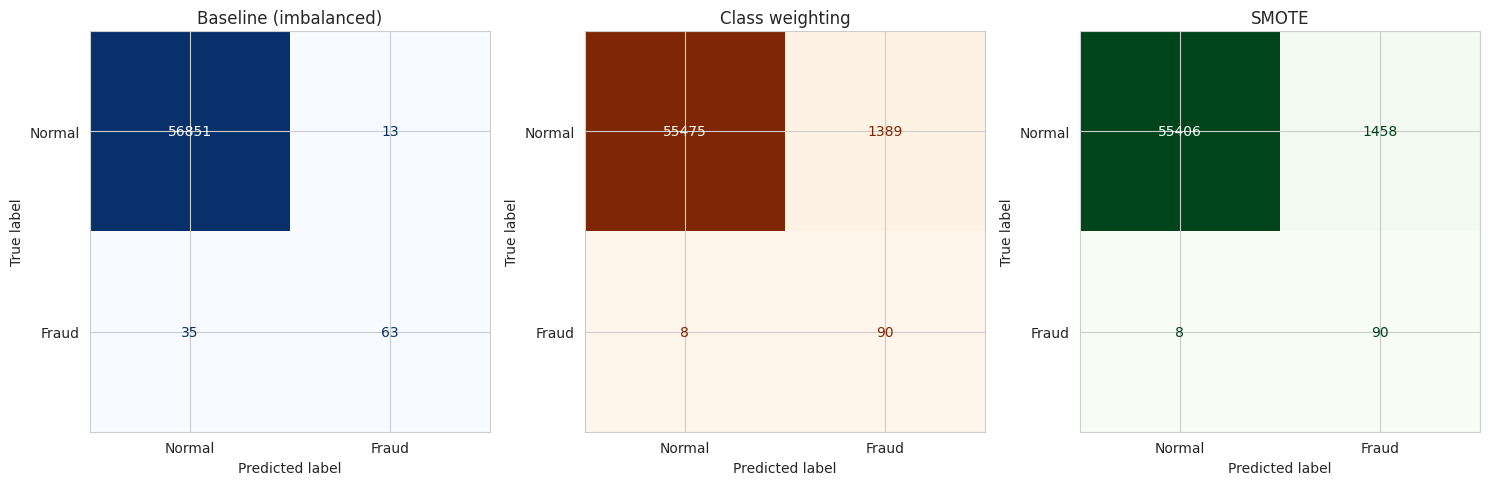

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Baseline (imbalanced)", "Class weighting", "SMOTE"]
preds = [y_pred_baseline, y_pred_weighted, y_pred_smote]
cmaps = ["Blues", "Oranges", "Greens"]

for ax, title, pred, cmap in zip(axes, titles, preds, cmaps):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fraud"]).plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()


## 9. What changed, and why

*(Refer to the table above for this run's exact numbers.)* The baseline
model trained on the raw imbalanced data tends to have **high precision but
lower recall** on fraud — it only flags transactions it's very confident
about, so it misses a meaningful share of actual fraud. Both class weighting
and SMOTE typically **increase recall** (catching more real fraud cases) at
some cost to precision (more false alarms on normal transactions) — a
classic precision/recall trade-off. Which balance point is "better" is a
business decision, not just a modeling one: for fraud detection, missing
real fraud (a false negative) is usually far more costly than investigating
a false alarm (a false positive), so trading some precision for higher
recall is often the right call — accuracy alone would never have revealed
this trade-off existed.
